# keras 로 모델 만드는 방법들


**keras 에서 모델 만드는 방법 3가지**
https://keras.io/api/models/model/
-    Functional API
-    keras.Model 상속
-    Sequential

![](https://wikidocs.net/images/page/106897/1_WzwKtnA0LEhiCGdWTTpLaA.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Sequential API 로 모델 작성
- 모델이 layer 들을 단순히 선형으로 쌓아 올리는 형태인 경우 간단하게 사용가능
- https://keras.io/guides/sequential_model/
- https://keras.io/api/models/sequential/

In [2]:
# Sequential() 객체 생성후 add() 로 layer 추가하기
model = keras.Sequential()
model.add(keras.Input(shape=(None, None, 3)))
model.add(keras.layers.Conv2D(filters=32, kernel_size=3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, None, None, 32) │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

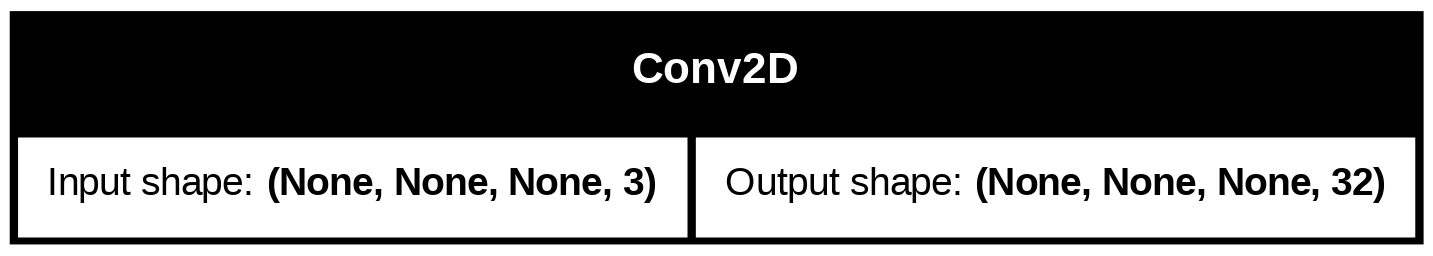

In [3]:
keras.utils.plot_model(model, show_shapes=True)

In [4]:
# Sequential() 객체 생성시 layer 를 추가하기
model = keras.Sequential([
    keras.Input(shape=(None, None, 3)),
    keras.layers.Conv2D(filters=32, kernel_size=3),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, None, None, 32) │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

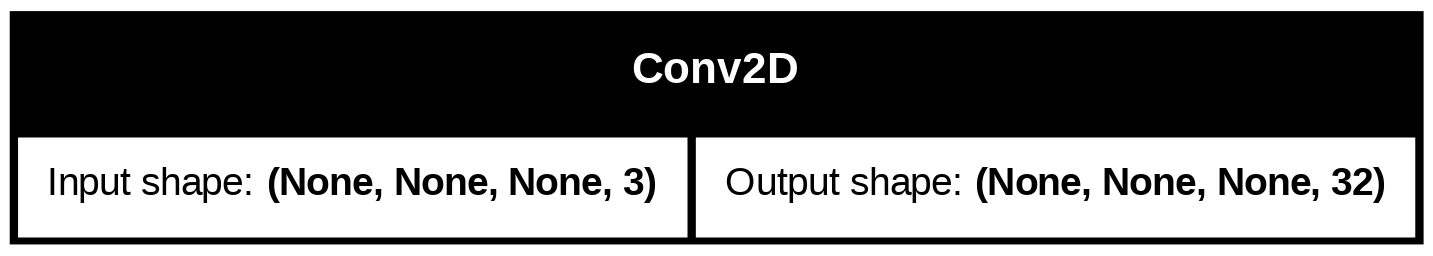

In [5]:
keras.utils.plot_model(model, show_shapes=True)

# Functional API로 모델 작성
- 함수형 API
- Sequential API는 여러층을 공유하거나 다양한 종류의 입력과 출력을 사용하는 등의 복잡한 모델을 만드는 일에는 한계가 있다
- https://keras.io/guides/functional_api/

In [6]:
inputs = keras.Input(shape=(37,))
x = keras.layers.Dense(32, activation='relu')(inputs) # 객체호출 구문, __call__()
outputs = keras.layers.Dense(5, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381 (5.39 KB)

 Trainable params: 1,381 (5.39 KB)

 Non-trainable params: 0 (0.00 B)

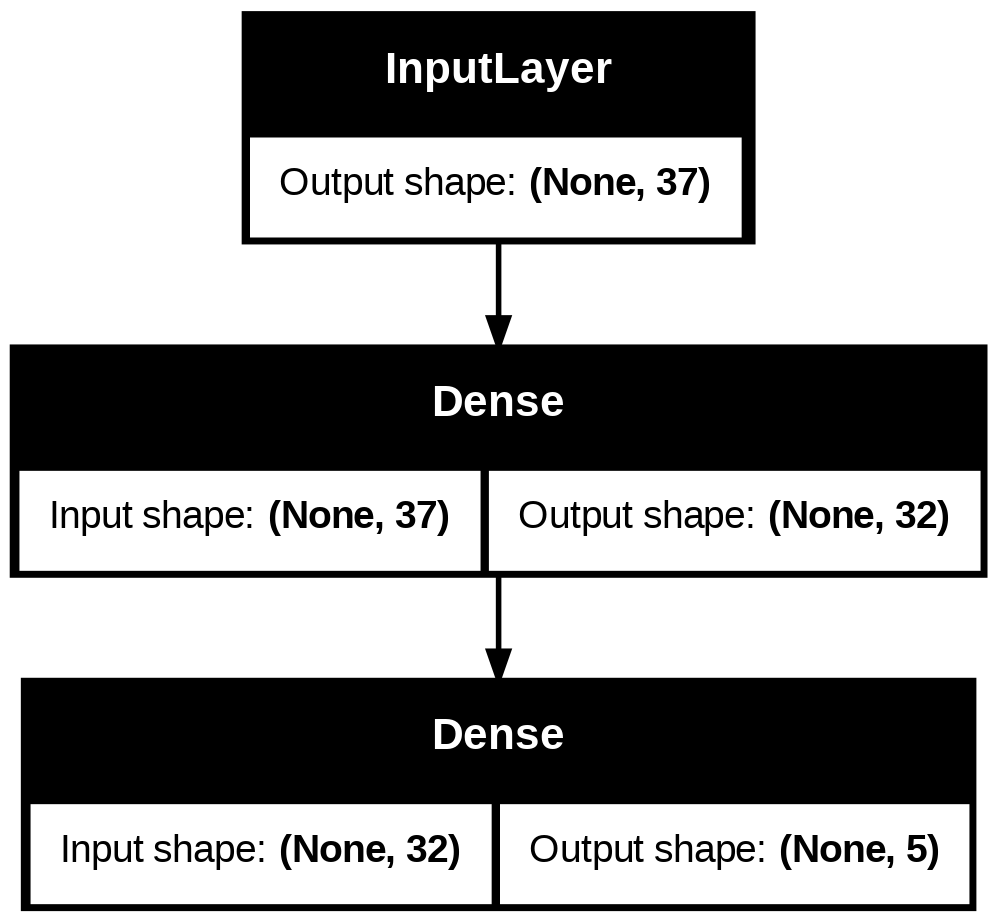

In [7]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Functional API 로는 복잡한 모델 생성 가능
#  - input 도 여러개 (다중입력)
#  - output 도 여러개 (다중 출력)
#  - 복잡한 layer 구조
#    - ex) 중첩된 구조, 재귀적 구조, 공유 구조 ..
#  - 데이터 흐름이 차례대로 진행되지 않는 모델 (ex: resnet)

In [8]:
num_tags = 12
num_words = 10000
num_departments = 4

# 입력이 여러개
title_input = keras.Input(shape=(None,), name="title")
body_input = keras.Input(shape=(None,), name="body")
tags_input = keras.Input(shape=(num_tags,), name='tags')

title_features = keras.layers.Embedding(num_words, 64)(title_input)
body_features = keras.layers.Embedding(num_words, 64)(body_input)

title_features = keras.layers.LSTM(128)(title_features)
body_features = keras.layers.LSTM(32)(body_features)

x = keras.layers.concatenate([title_features, body_features, tags_input])

# 여러개의 출력
priority_pred = keras.layers.Dense(1, name='priority')(x)
department_pred = keras.layers.Dense(num_departments, name='department')(x)

model = keras.Model(
    inputs=[title_input, body_input, tags_input],
    outputs={"priority": priority_pred, "department": department_pred},
)

model.summary()






Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (InputLayer)   │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │    640,000 │ title[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │    640,000 │ body[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 12)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 172)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        692 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │        173 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,392,097 (5.31 MB)

 Trainable params: 1,392,097 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

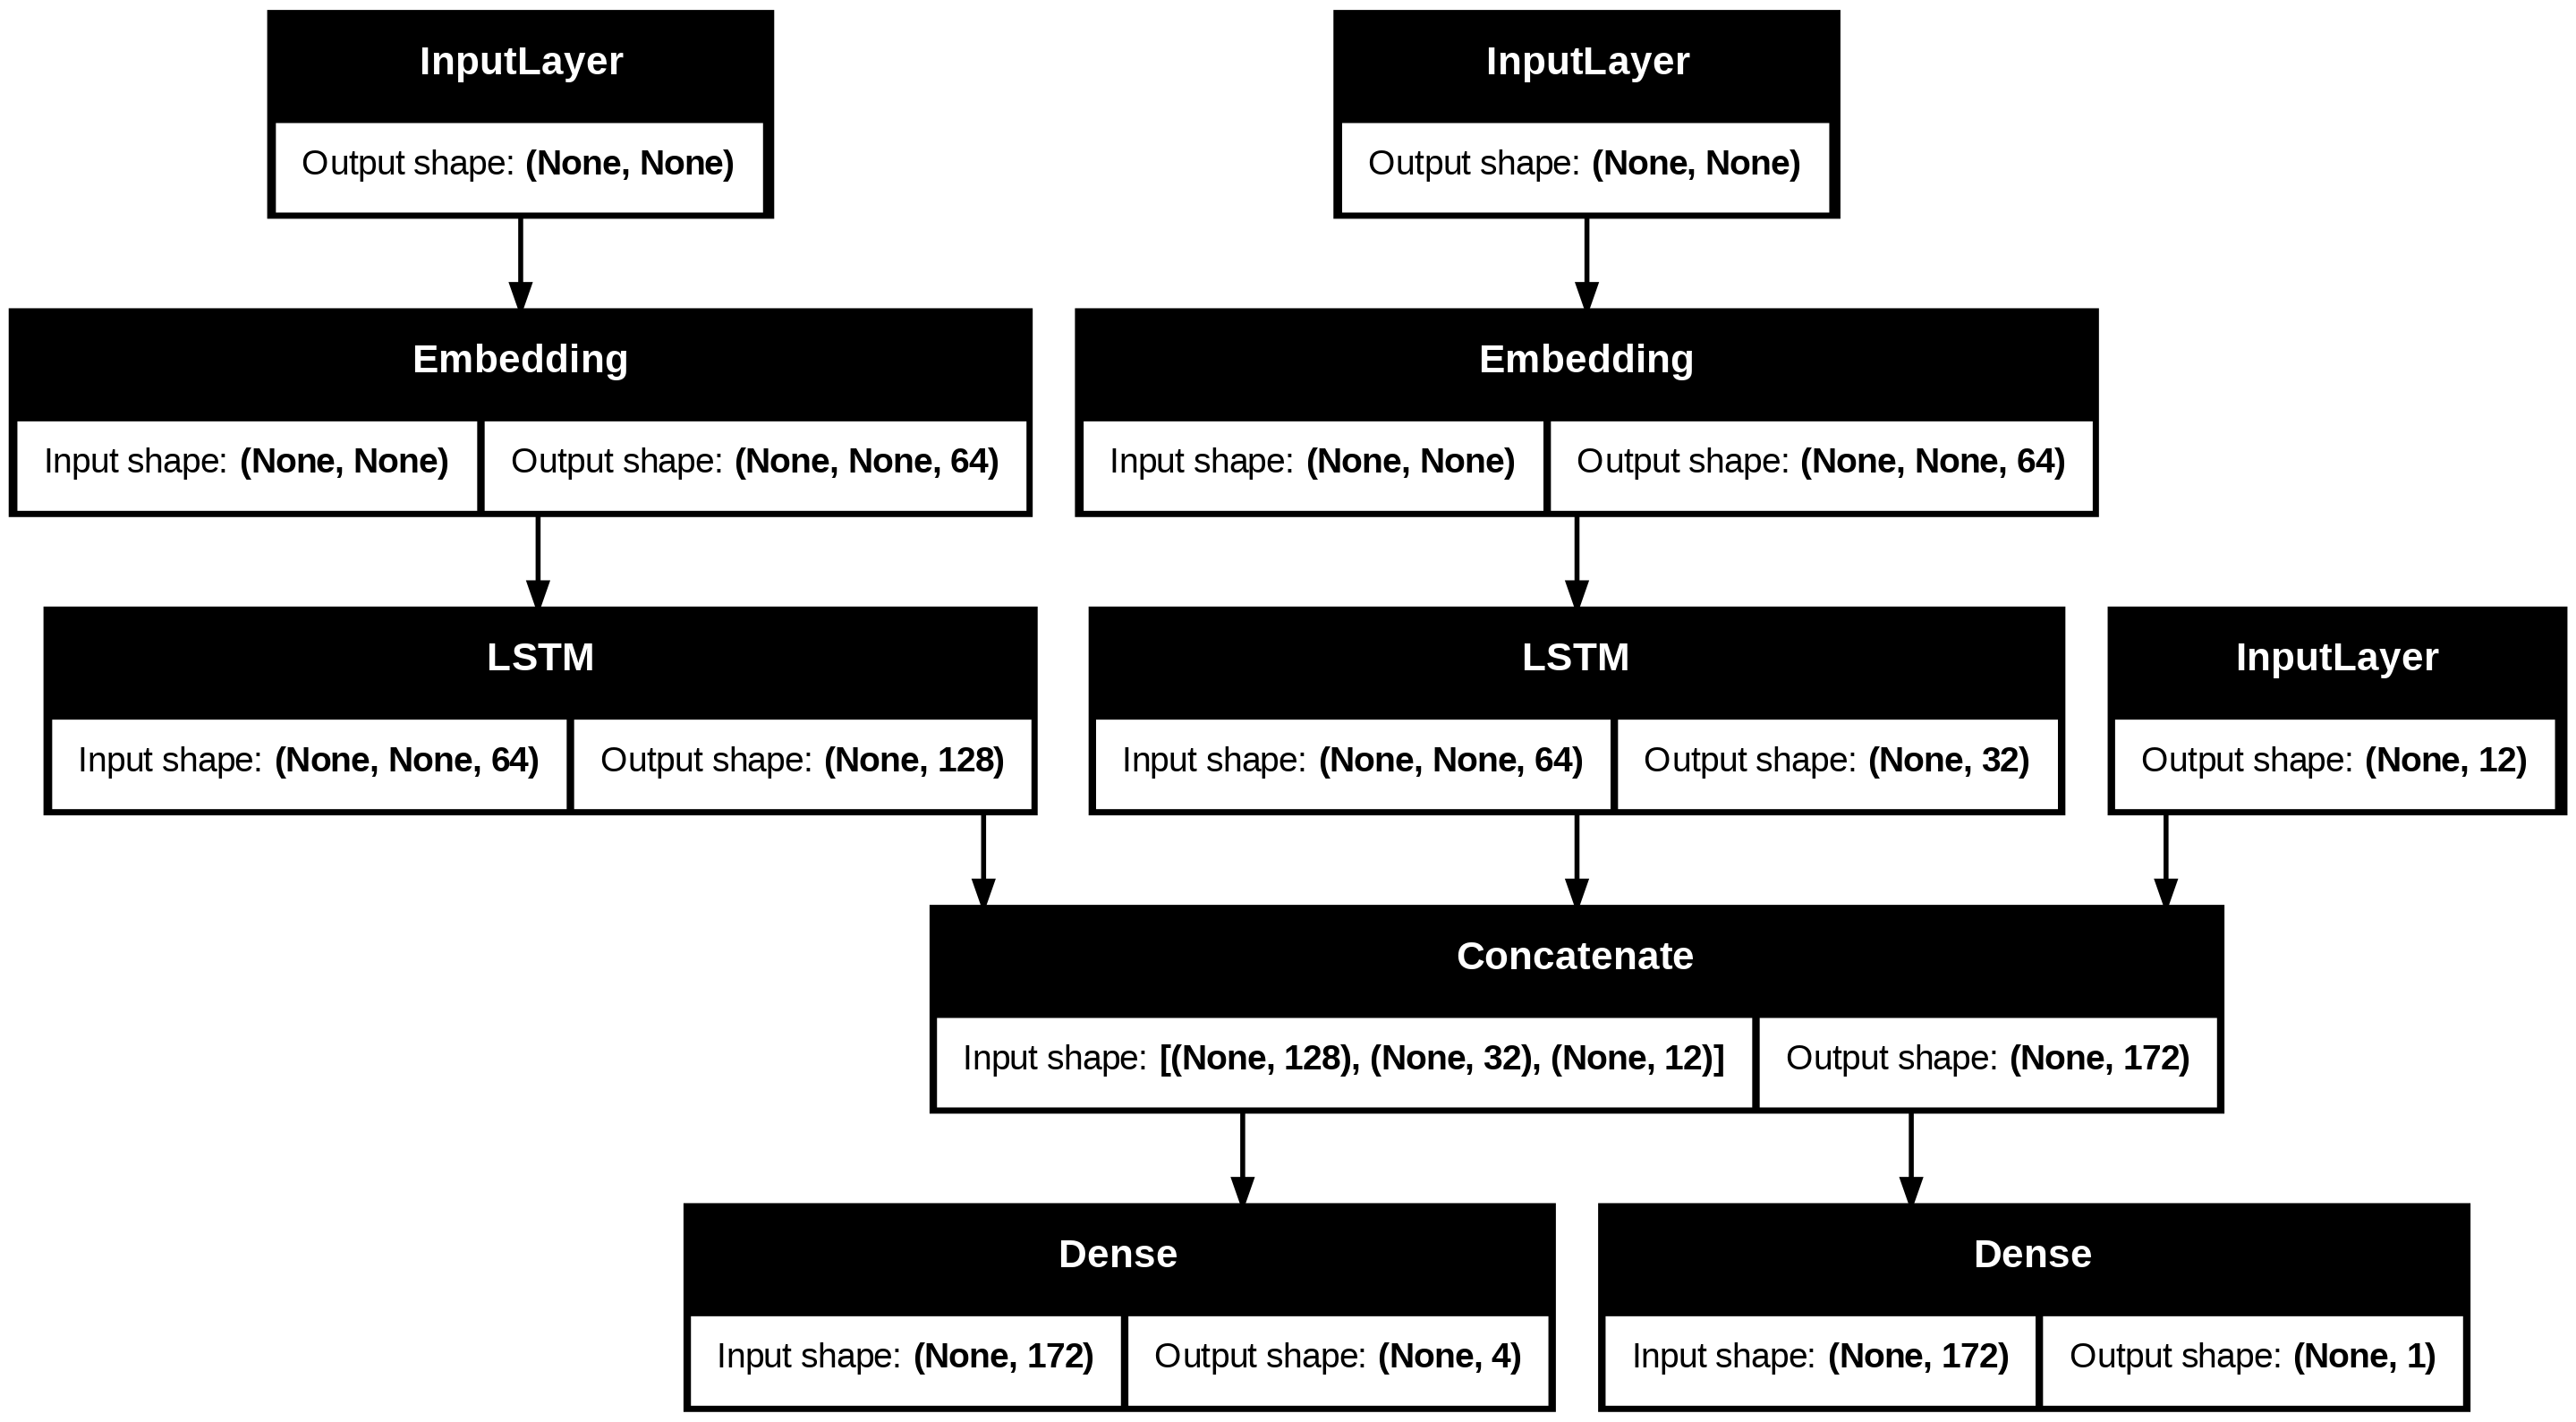

In [9]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# keras 함수형 모델 방식으로 구현하면  복잡한 구조 가능.

input_layer1 = keras.layers.Input(shape=(28, 28, 1))  # 입력크기

conv1 = keras.layers.Conv2D(128, 3, padding='valid', activation='relu')(input_layer1)
pool1 = keras.layers.MaxPooling2D(2)(conv1)

conv2 = keras.layers.Conv2D(128, 3, padding='valid', activation='relu')(input_layer1)
pool2 = keras.layers.MaxPooling2D(2)(conv2)

conv3 = keras.layers.Conv2D(128, 3, padding='valid', activation='relu')(input_layer1)
pool3 = keras.layers.MaxPooling2D(2)(conv3)

# 3,4,5 이후 합치기
concat = keras.layers.concatenate([pool1, pool2, pool3])

hidden = keras.layers.Dense(128, activation=tf.nn.relu)(concat)
dropout_hidden = keras.layers.Dropout(rate=0.7)(hidden)
logits = keras.layers.Dense(5, name='logits')(dropout_hidden)  # 최종적으로 5가지 의도 클래스를 분류. 결과로 나온 값(logits) 을을 점수(score) 라 부른다
predictions = keras.layers.Dense(5, activation=tf.nn.softmax)(logits)

model = keras.Model(
    inputs=[input_layer1],
    outputs={"predictions": predictions},
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 28, 28, 1)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 26, 26, 128)    │          1,280 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 26, 26, 128)    │          1,280 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 26, 26, 128)    │          1,280 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 13, 13, 128)    │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 13, 13, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 13, 13, 128)    │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 13, 13, 384)    │              0 │ max_pooling2d[0][0],   │
│ (Concatenate)             │                        │                │ max_pooling2d_1[0][0], │
│                           │                        │                │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 13, 13, 128)    │         49,280 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 13, 13, 128)    │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ logits (Dense)            │ (None, 13, 13, 5)      │            645 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 13, 13, 5)      │             30 │ logits[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 53,795 (210.14 KB)

 Trainable params: 53,795 (210.14 KB)

 Non-trainable params: 0 (0.00 B)

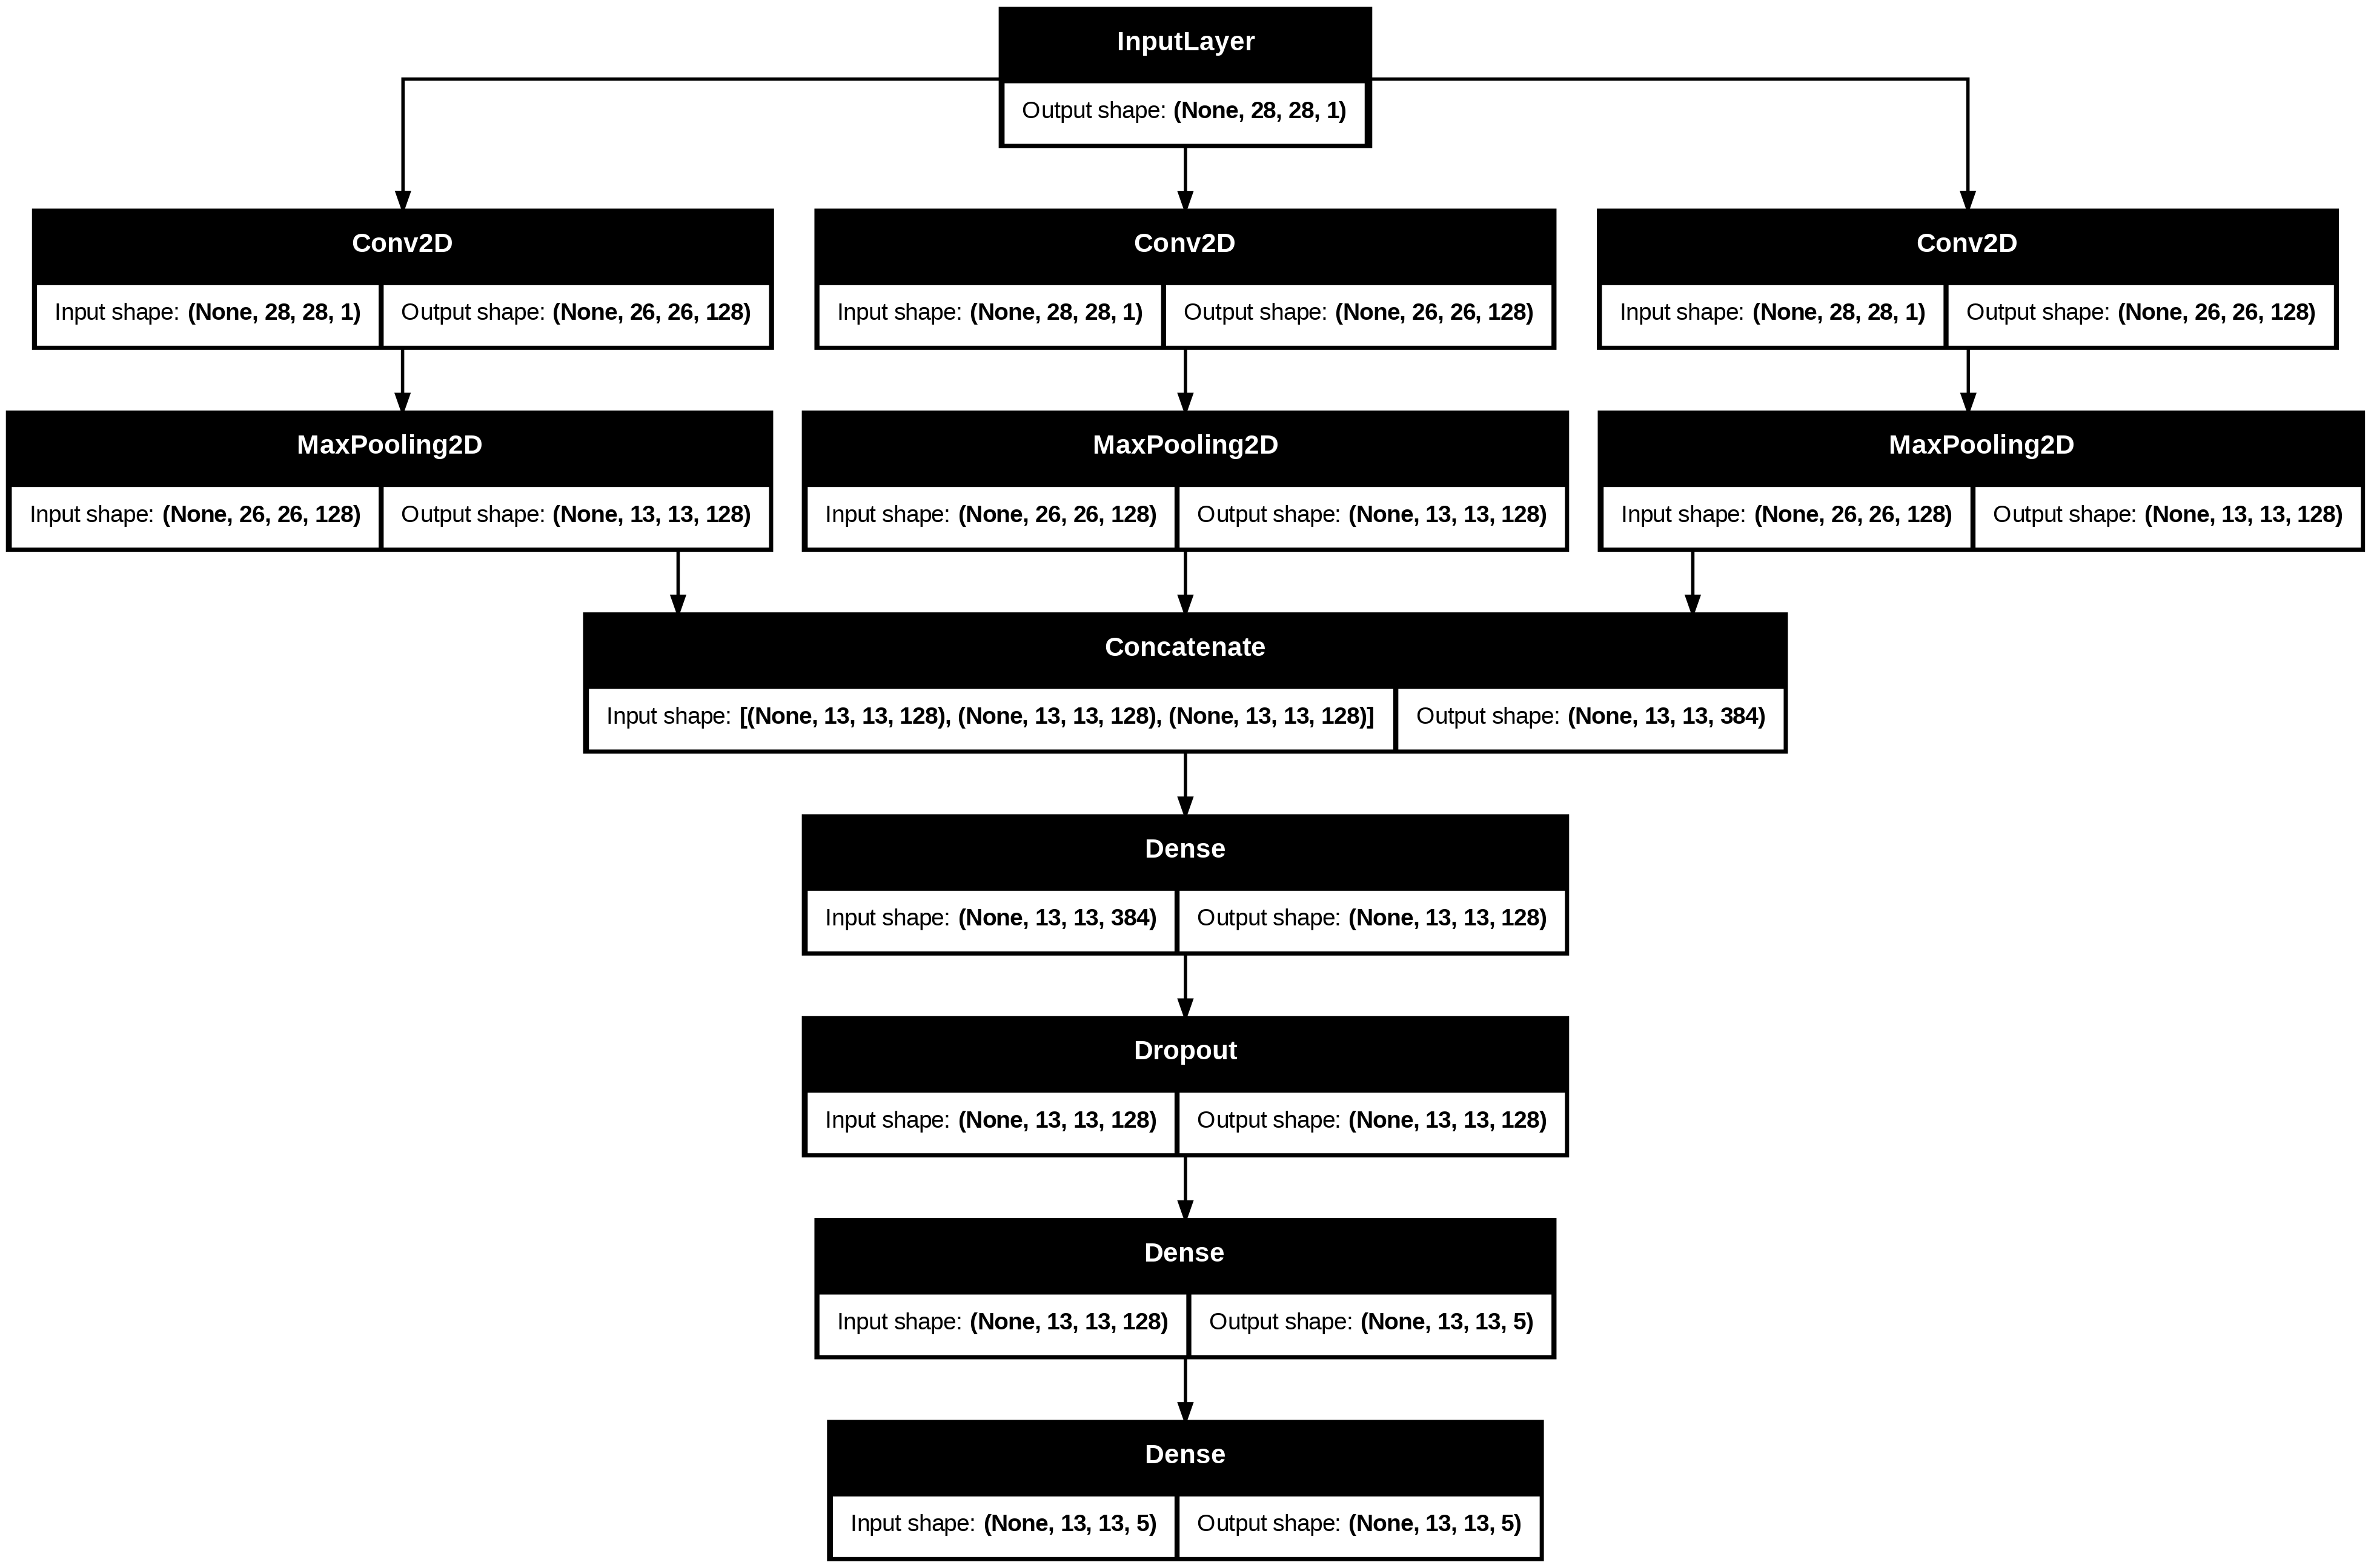

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

# Subclassing API 로 모델 작성
- keras.Model 클래스를 상속받아 모델 생성
  - https://keras.io/api/models/model/
- __init__() 에서 layer 들 정의
- call() 을 구현하여 forward pass 정의
- Functional API가 구현할 수 없는 모델들조차 구현할 수 있는 경우가 있다.
  - Functional API는 기본적으로 딥 러닝 모델을 DAG(directed acyclic graph)로 취급.
  - 실제로 대부분의 딥 러닝 모델이 이에 속하기는 하지만, 항상 그렇지는 않습니다.
  - ex) 재귀 네트워크나 트리 RNN은 이 가정을 따르지 않으며 Functional API에서 구현할 수 없습니다.

- 대부분의 딥 러닝 모델은 Functional API 수준에서도 전부 구현이 가능하다. 그래서 Subclassing API는 밑바닥부터 새로운 수준의 아키텍처를 구현해야 하는 실험적 연구를 하는 연구자들에게 적합

In [ ]:
class MyModel(keras.Model):

  # layer 들 정의
  def __init__(self, num_classes=10):
    super(MyModel, self).__init__(name="my_model")
    self.num_classes = num_classes
    self.dense_1 = keras.layers.Dense(32, activation='relu')
    self.dense_2 = keras.layers.Dense(num_classes, activation='softmax')

  # call(self, inputs, training=False, **kwargs) 을 정의해야 한다
  #   내부적으로 TF 가 내부적으로 __call__() 을 처리한다 (사용자가 __call__ 을 건드릴 필요없다 )
  #   역할: 모델의 순방향(정방향) 패스(forward pass)를 정의합니다.
  #   `__init__` 메서드에서 정의한 층을 사용합니다.
  #   plot_model()은 내부적으로 모델의 레이어 연결을 따라가야 하기 때문에,
  #   이 call() 메서드가 올바르게 정의되어야 합니다.
  #   필요하다면 training=False 으로 학습/추론 구분 로직을 넣을수 있다.
  def call(self, inputs):
    x = self.dense_1(inputs) # 객체호출
    return self.dense_2(x)

model = MyModel()

model.summary()


Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model = MyModel()

inputs = keras.layers.Input(shape=(32,))
outputs = model(inputs)

model_with_inputs = keras.Model(inputs=inputs, outputs=outputs)

model_with_inputs.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ my_model (MyModel)                   │ (None, 10)                  │           1,386 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,386 (5.41 KB)

 Trainable params: 1,386 (5.41 KB)

 Non-trainable params: 0 (0.00 B)

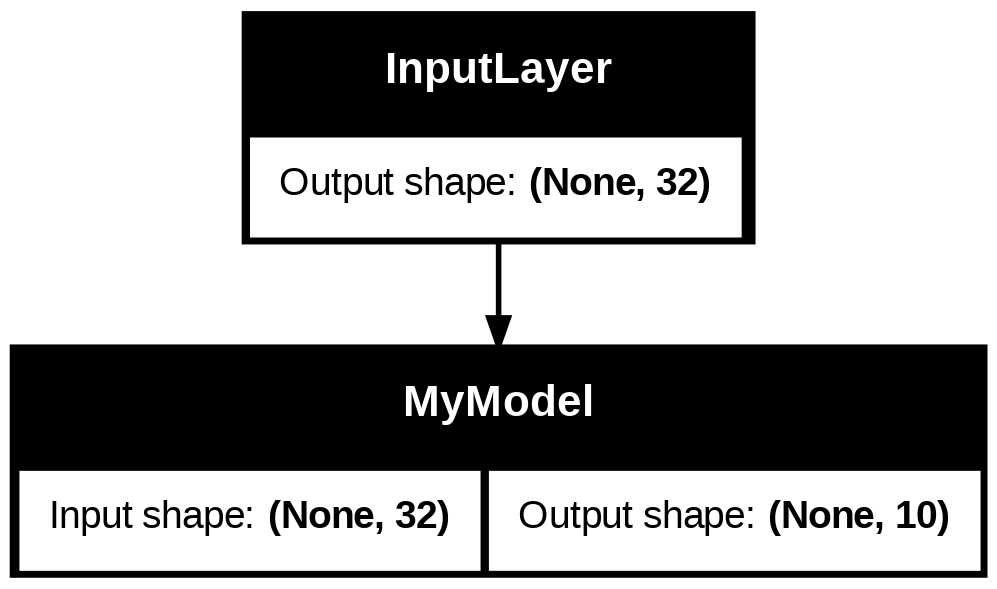

In [ ]:
keras.utils.plot_model(model_with_inputs, show_shapes=True)

# 정리] 세가지 구현 방식 비교
1. Sequential API
  - 장점 : 단순하게 층을 쌓는 방식으로 쉽고 사용하기가 간단합니다.
  - 단점 : 다수의 입력(multi-input), 다수의 출력(multi-output)을 가진 모델 또는 층 간의 연결(concatenate)이나 덧셈(Add)과 같은 연산을 하는 모델을 구현하기에는 적합하지 않습니다. 이런 모델들의 구현은 Functional API를 사용해야 합니다.

1. Functional API
  - 장점 : Sequential API로는 구현하기 어려운 복잡한 모델들을 구현할 수 있습니다.
  - 단점 : 입력의 크기(shape)를 명시한 입력층(Input layer)을 모델의 앞단에 정의해주어야 합니다.

1. Subclassing API  
  - 장점 : Functional API로도 구현할 수 없는 모델들조차 구현이 가능합니다.
  - 단점 : 객체 지향 프로그래밍(Object-oriented programming)에 익숙해야 하므로 코드 사용이 가장 까다롭습니다.